# Exploratory Data Analysis — VC Investments\n\nThis notebook explores the `investments_VC.csv` dataset: startup funding rounds, geographies, markets, and funding amounts."

StageWhat it meansangelVery early — friends, family, angel investors. Often pre-product.grantNon-dilutive funding, common in biotech/researchconvertible_noteBridge funding, often pre-seed or between roundsseedFirst "official" institutional round — product exists, some tractionround_ASeries A — scaling a proven model

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('assets/investments_VC.csv', encoding='latin-1')

# Clean funding_total_usd: remove commas/spaces and convert
df['funding_total_usd'] = (
    df[' funding_total_usd ']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('-', np.nan)
    .pipe(pd.to_numeric, errors='coerce')
)

print(f"Shape: {df.shape}")
df.head(3)

Shape: (54294, 40)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_total_usd
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1750000.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4000000.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40000.0


## 1. Dataset Overview

In [14]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Basic Stats ===")
df.describe(include='all').T

=== Data Types ===
permalink                   str
name                        str
homepage_url                str
category_list               str
 market                     str
 funding_total_usd          str
status                      str
country_code                str
state_code                  str
region                      str
city                        str
funding_rounds          float64
founded_at                  str
founded_month               str
founded_quarter             str
founded_year            float64
first_funding_at            str
last_funding_at             str
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
permalink,49438,49436,/organization/prysm,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,49437,49350,Roost,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homepage_url,45989,45850,http://www.360fly.com,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_list,45477,16675,|Software|,3650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,45470,753,Software,4620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funding_total_usd,49438,14617,-,8531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,48124,3,operating,41829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_code,44165,115,USA,28793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_code,30161,61,CA,9917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,44165,1089,SF Bay Area,6804,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Values

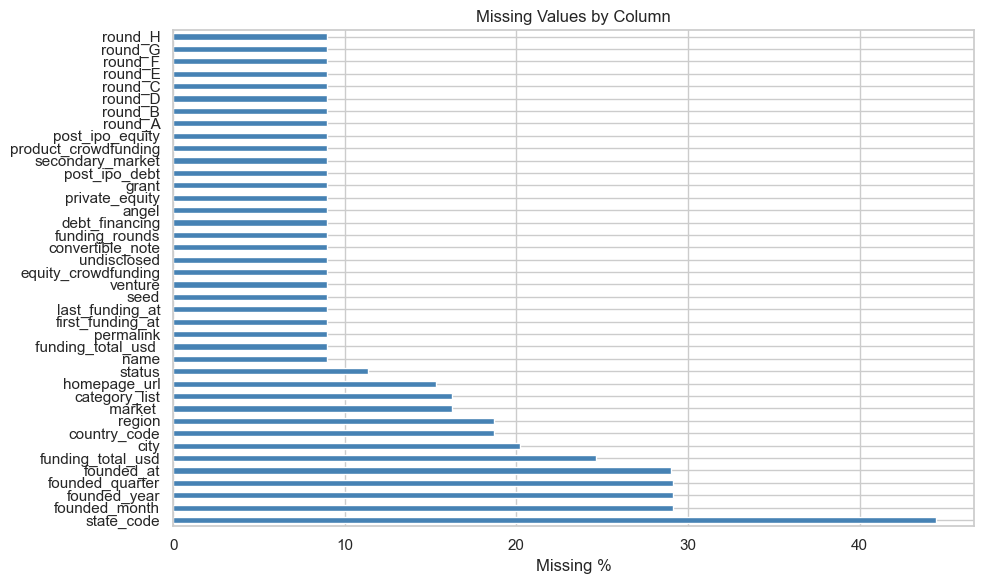

                      missing    pct
state_code              24133  44.45
founded_month           15812  29.12
founded_year            15812  29.12
founded_quarter         15812  29.12
founded_at              15740  28.99
funding_total_usd       13387  24.66
city                    10972  20.21
country_code            10129  18.66
region                  10129  18.66
 market                  8824  16.25
category_list            8817  16.24
homepage_url             8305  15.30
status                   6170  11.36
name                     4857   8.95
 funding_total_usd       4856   8.94
permalink                4856   8.94
first_funding_at         4856   8.94
last_funding_at          4856   8.94
seed                     4856   8.94
venture                  4856   8.94
equity_crowdfunding      4856   8.94
undisclosed              4856   8.94
convertible_note         4856   8.94
funding_rounds           4856   8.94
debt_financing           4856   8.94
angel                    4856   8.94
p

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0]

fig, ax = plt.subplots(figsize=(10, 6))
missing_df['pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

print(missing_df)

In [15]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


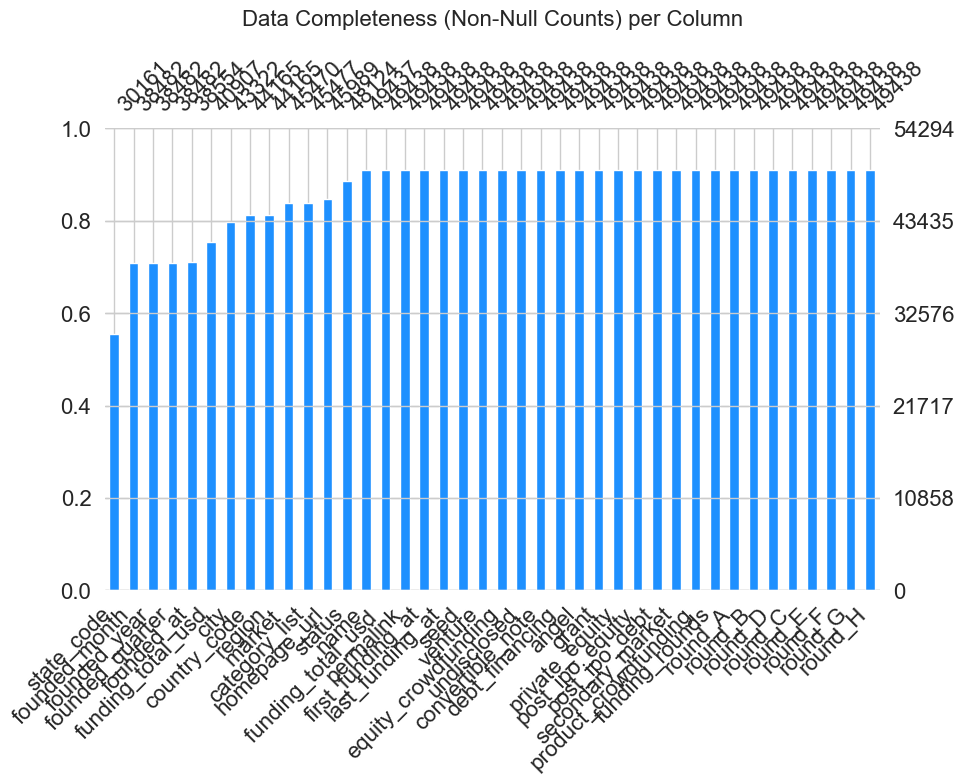

In [16]:
import missingno as msno
plt.figure(figsize=(10, 6))
msno.bar(df, color="dodgerblue", sort="ascending", figsize=(10, 6))
plt.title('Data Completeness (Non-Null Counts) per Column\n', fontsize=16)
plt.show()

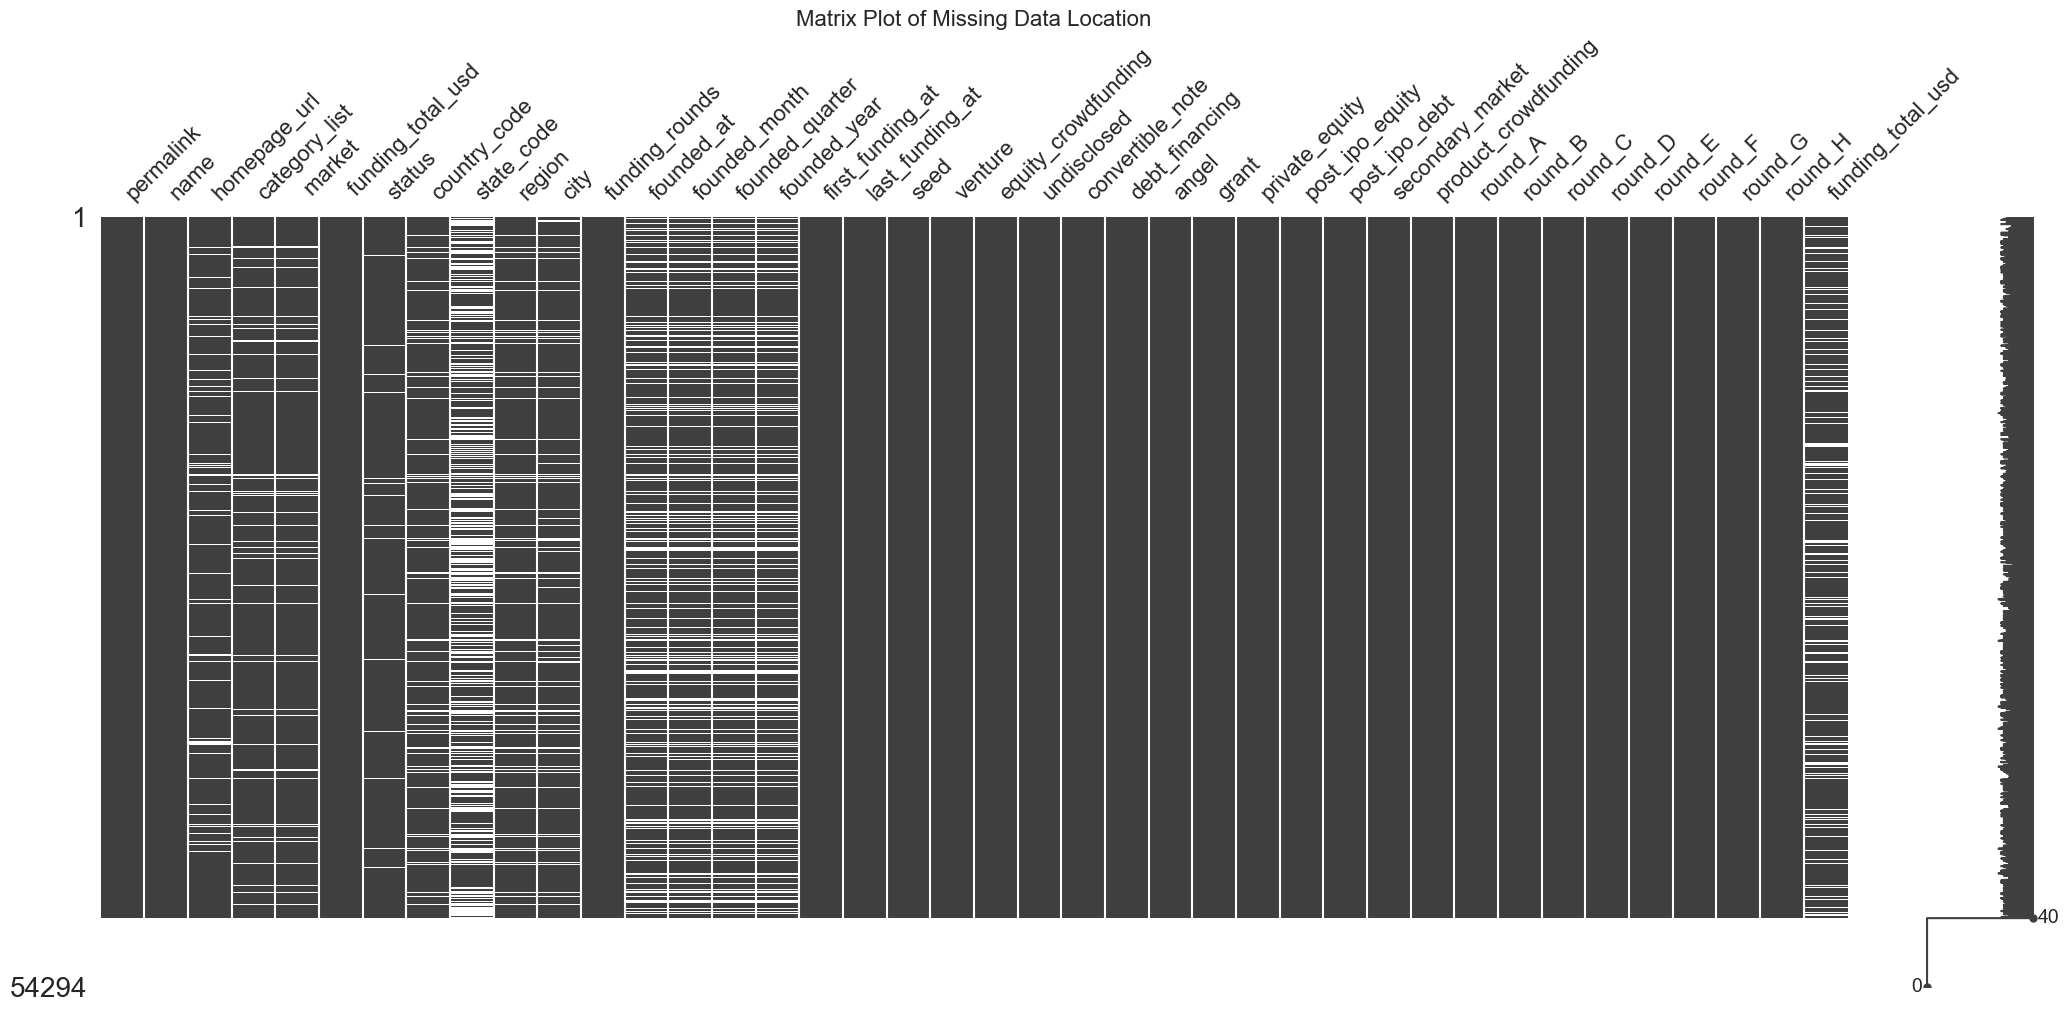

In [17]:
msno.matrix(df)
plt.title('Matrix Plot of Missing Data Location', fontsize=16)
plt.show()

<Figure size 1000x600 with 0 Axes>

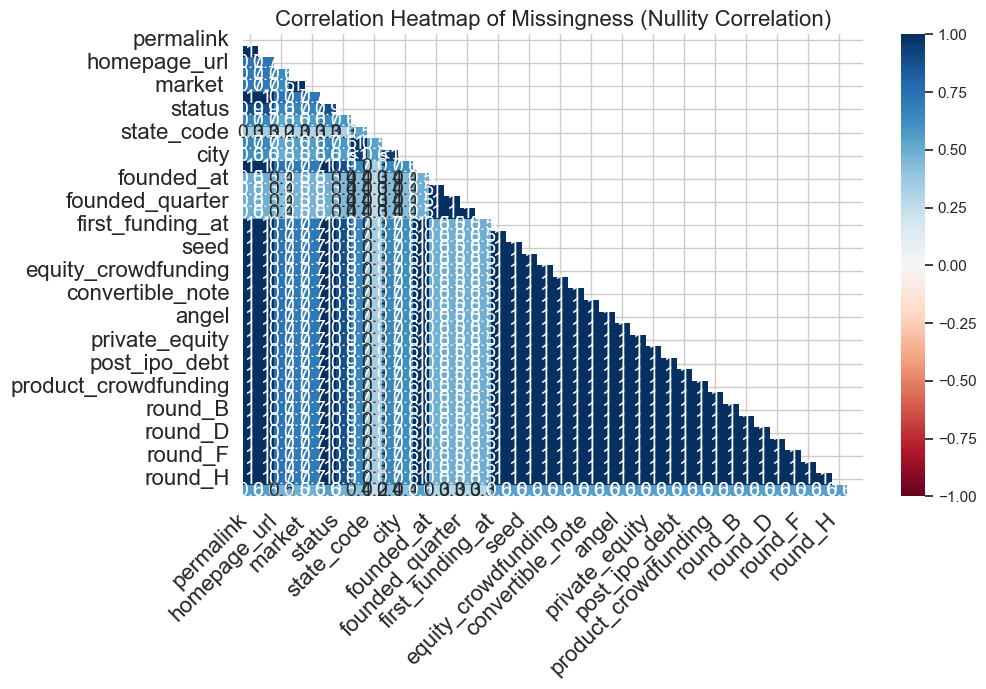

In [18]:
plt.figure(figsize=(10, 6))
msno.heatmap(df, figsize=(10, 6))
plt.title('Correlation Heatmap of Missingness (Nullity Correlation)', fontsize=16)
plt.show()

## 3. Company Status Distribution

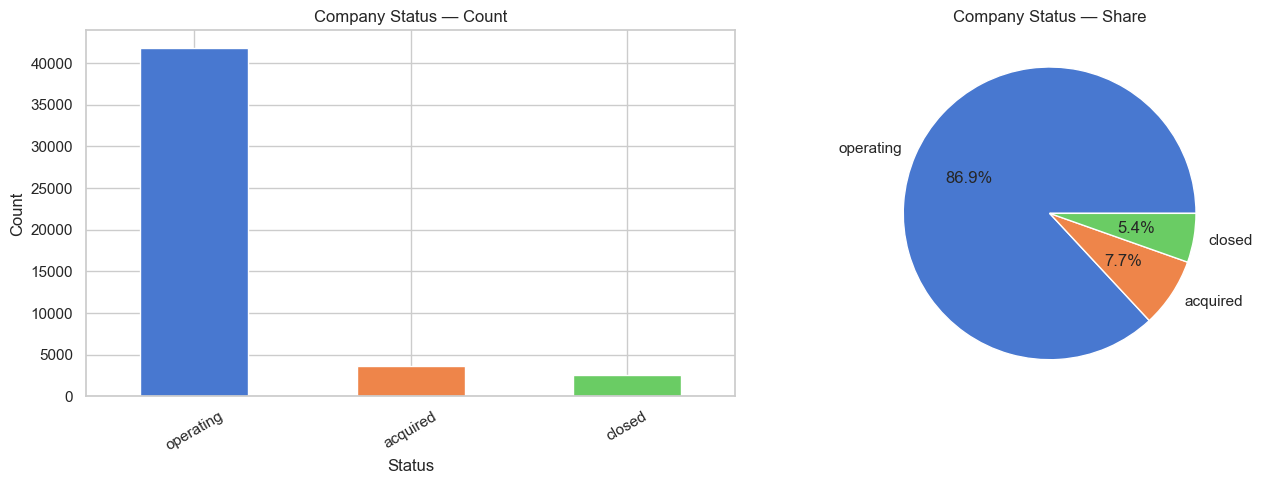

In [4]:
status_counts = df['status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'))
axes[0].set_title('Company Status — Count')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'))
axes[1].set_title('Company Status — Share')

plt.tight_layout()
plt.show()

## 4. Top Countries & Markets

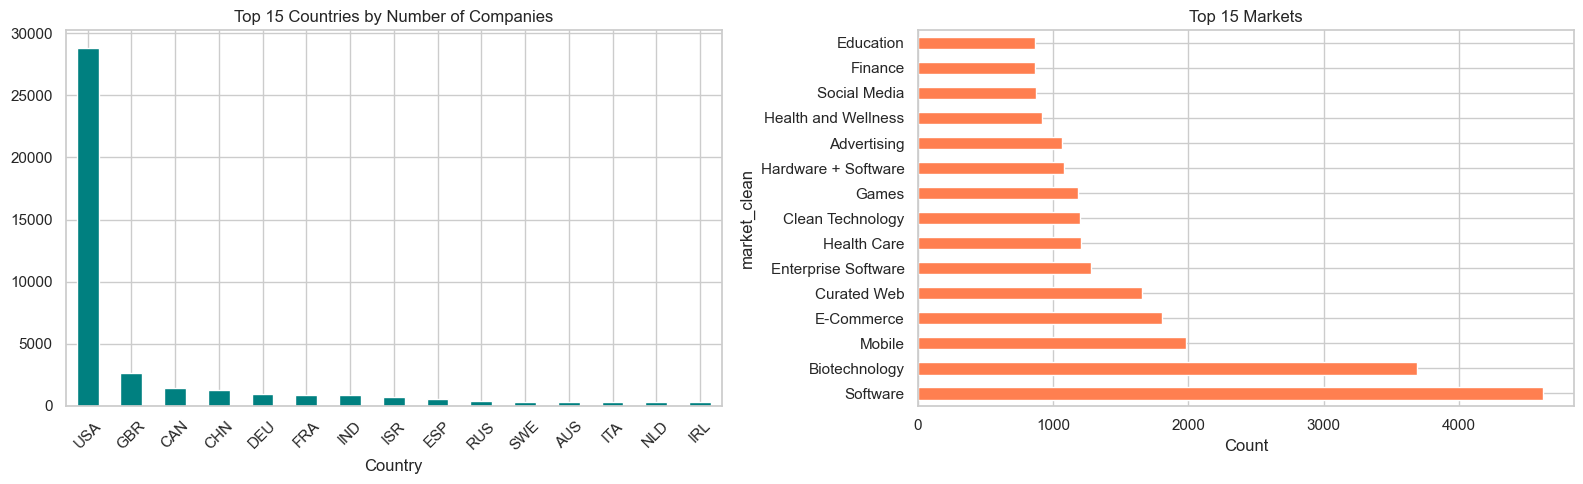

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['country_code'].value_counts().head(15).plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Countries by Number of Companies')
axes[0].set_xlabel('Country')
axes[0].tick_params(axis='x', rotation=45)

# Clean market column
df['market_clean'] = df[' market '].str.strip().str.strip('|')
df['market_clean'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Markets')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 5. Funding Distribution

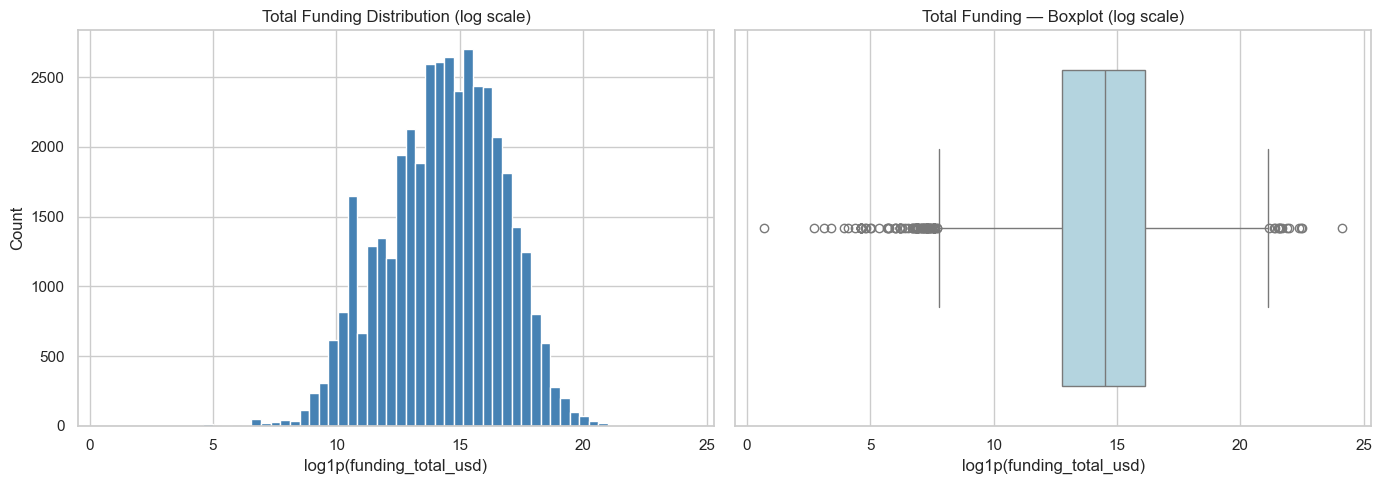

count            $40,907
mean         $15,912,526
std         $168,678,800
min                   $1
25%             $350,000
50%           $2,000,000
75%          $10,000,000
max      $30,079,503,000
Name: funding_total_usd, dtype: str


In [6]:
fund = df['funding_total_usd'].dropna()
fund_log = np.log1p(fund[fund > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fund_log, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Total Funding Distribution (log scale)')
axes[0].set_xlabel('log1p(funding_total_usd)')
axes[0].set_ylabel('Count')

sns.boxplot(x=fund_log, ax=axes[1], color='lightblue')
axes[1].set_title('Total Funding — Boxplot (log scale)')
axes[1].set_xlabel('log1p(funding_total_usd)')

plt.tight_layout()
plt.show()

print(fund.describe().apply(lambda x: f"${x:,.0f}"))

## 6. Funding Rounds Analysis

In [ ]:
late_rounds = ['round_D', 'round_E', 'round_F', 'round_G', 'round_H']
df['round_D+'] = df[late_rounds].sum(axis=1)

round_cols = ['seed', 'venture', 'angel', 'round_A', 'round_B', 'round_C', 'round_D+',
              'private_equity', 'debt_financing', 'grant', 'equity_crowdfunding']

round_totals = df[round_cols].sum().sort_values(ascending=False) / 1e9

fig, ax = plt.subplots(figsize=(14, 5))
round_totals.plot(kind='bar', ax=ax, color=sns.color_palette('tab20'))
ax.set_title('Total Funding by Round Type (USD Billions)')
ax.set_ylabel('USD Billions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Companies per number of funding rounds
fig, ax = plt.subplots(figsize=(10, 4))
df['funding_rounds'].value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Companies by Number of Funding Rounds')
ax.set_xlabel('Funding Rounds')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 6b. Is `funding_total_usd` the Sum of All Rounds?

In [ ]:
all_round_cols = ['seed', 'venture', 'angel', 'round_A', 'round_B', 'round_C',
                  'round_D', 'round_E', 'round_F', 'round_G', 'round_H',
                  'equity_crowdfunding', 'undisclosed', 'convertible_note',
                  'debt_financing', 'grant', 'private_equity',
                  'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

df['rounds_sum'] = df[all_round_cols].sum(axis=1)

# ── 1. How well does rounds_sum match funding_total_usd? ─────────────────────
has_both = df[df['funding_total_usd'].notna() & (df['rounds_sum'] > 0)].copy()
has_both['diff'] = (has_both['funding_total_usd'] - has_both['rounds_sum']).abs()
has_both['pct_diff'] = has_both['diff'] / has_both['funding_total_usd'].replace(0, np.nan) * 100

exact      = (has_both['diff'] < 1).sum()
within_1pct= (has_both['pct_diff'] < 1).sum()
total_both = len(has_both)

print("=== Does rounds_sum ≈ funding_total_usd? ===")
print(f"Rows with both values:          {total_both:,}")
print(f"Exact match (diff < $1):        {exact:,}  ({exact/total_both:.1%})")
print(f"Within 1% difference:           {within_1pct:,}  ({within_1pct/total_both:.1%})")
print(f"\nMedian absolute difference:     ${has_both['diff'].median():,.0f}")
print(f"Mean absolute difference:       ${has_both['diff'].mean():,.0f}")

# ── 2. Null analysis ─────────────────────────────────────────────────────────
null_total = df['funding_total_usd'].isna()
print(f"\n=== Null funding_total_usd: {null_total.sum():,} rows ===")

null_df = df[null_total].copy()
null_df['rounds_sum'] = null_df[all_round_cols].sum(axis=1)

can_impute   = (null_df['rounds_sum'] > 0).sum()
truly_zero   = (null_df['rounds_sum'] == 0).sum()

print(f"  rounds_sum > 0  → CAN impute:   {can_impute:,}  ({can_impute/null_total.sum():.1%})")
print(f"  rounds_sum == 0 → truly unknown: {truly_zero:,}  ({truly_zero/null_total.sum():.1%})")

# ── 3. Scatter: rounds_sum vs funding_total_usd ───────────────────────────────
sample = has_both.sample(min(3000, len(has_both)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.log1p(sample['rounds_sum']),
                np.log1p(sample['funding_total_usd']),
                alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 25], [0, 25], 'r--', linewidth=1, label='perfect match')
axes[0].set_xlabel('log1p(rounds_sum)')
axes[0].set_ylabel('log1p(funding_total_usd)')
axes[0].set_title('rounds_sum vs funding_total_usd (log scale)')
axes[0].legend()

axes[1].hist(np.log1p(null_df[null_df['rounds_sum'] > 0]['rounds_sum']),
             bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Imputable Nulls — Distribution of rounds_sum')
axes[1].set_xlabel('log1p(rounds_sum)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ── 4. Conclusion ─────────────────────────────────────────────────────────────
print("\n=== Conclusion ===")
print(f"funding_total_usd ≈ sum of rounds for most rows (check scatter above).")
print(f"{can_impute:,} null rows can be filled with rounds_sum.")
print(f"{truly_zero:,} null rows have no round data — cannot be recovered.")

In [ ]:
before = df['funding_total_usd'].isna().sum()

df['funding_total_usd'] = df['funding_total_usd'].fillna(
    df['rounds_sum'].replace(0, np.nan)
)

after = df['funding_total_usd'].isna().sum()
filled = before - after

print(f"Nulls before: {before:,}")
print(f"Nulls after:  {after:,}")
print(f"Filled:       {filled:,} rows imputed from rounds_sum")

In [ ]:
null_status = df[df['funding_total_usd'].isna()]['status'].value_counts()
all_status  = df['status'].value_counts()

status_compare = pd.DataFrame({
    'null_funding': null_status,
    'all_rows':     all_status,
}).fillna(0).astype(int)
status_compare['null_%_of_group'] = (
    status_compare['null_funding'] / status_compare['all_rows'] * 100
).round(1)

print(status_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

null_status.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Null funding_total_usd — Count by Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 10),
                     ha='center', fontsize=9)

status_compare['null_%_of_group'].plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Null funding_total_usd — % Within Each Status Group')
axes[1].set_ylabel('% Null')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.2),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
null_pct = df['funding_total_usd'].isna().mean() * 100
print(f"Remaining nulls: {df['funding_total_usd'].isna().sum():,} ({null_pct:.1f}%)")
print(f"Strategy: {'drop' if null_pct < 5 else 'group median imputation'}\n")

if null_pct < 5:
    df = df[df['funding_total_usd'].notna()].copy()
    print(f"Dropped null rows. Remaining: {len(df):,}")
else:
    # Group median with fallback chain:
    # 1st try: market + country_code + funding_rounds  (most specific)
    # 2nd try: market + country_code
    # 3rd try: market only
    # 4th try: overall median
    df['market_clean'] = df[' market '].str.strip().str.strip('|').str.strip()

    before = df['funding_total_usd'].isna().sum()

    g1 = df.groupby(['market_clean', 'country_code', 'funding_rounds'])['funding_total_usd'].transform('median')
    g2 = df.groupby(['market_clean', 'country_code'])['funding_total_usd'].transform('median')
    g3 = df.groupby('market_clean')['funding_total_usd'].transform('median')
    g4 = df['funding_total_usd'].median()

    df['funding_total_usd'] = (
        df['funding_total_usd']
        .fillna(g1)
        .fillna(g2)
        .fillna(g3)
        .fillna(g4)
    )

    after = df['funding_total_usd'].isna().sum()
    filled = before - after

    print(f"Nulls before: {before:,}")
    print(f"Nulls after:  {after:,}")
    print(f"Filled:       {filled:,} rows via group median imputation")
    print(f"\nFallback chain used:")
    print(f"  1. market + country + funding_rounds median")
    print(f"  2. market + country median")
    print(f"  3. market median")
    print(f"  4. overall median = ${g4:,.0f}")

In [ ]:
from sklearn.impute import KNNImputer

df['market_clean'] = df[' market '].str.strip().str.strip('|').str.strip()

null_mask = df['funding_total_usd'].isna()
print(f"Rows to fill: {null_mask.sum():,}\n")

# ── Method 1: Group Median (fallback chain) ───────────────────────────────────
df_m1 = df.copy()

g1 = df_m1.groupby(['market_clean', 'country_code', 'funding_rounds'])['funding_total_usd'].transform('median')
g2 = df_m1.groupby(['market_clean', 'country_code'])['funding_total_usd'].transform('median')
g3 = df_m1.groupby('market_clean')['funding_total_usd'].transform('median')
g4 = df_m1['funding_total_usd'].median()

df_m1['funding_total_usd'] = (
    df_m1['funding_total_usd']
    .fillna(g1).fillna(g2).fillna(g3).fillna(g4)
)

print(f"Method 1 — Group Median")
print(f"  Nulls remaining: {df_m1['funding_total_usd'].isna().sum():,}")
print(f"  Filled values — median: ${df_m1.loc[null_mask, 'funding_total_usd'].median():,.0f}")
print(f"  Filled values — mean:   ${df_m1.loc[null_mask, 'funding_total_usd'].mean():,.0f}\n")

# ── Method 2: KNN Imputer ─────────────────────────────────────────────────────
df_m2 = df.copy()

knn_features = ['funding_total_usd', 'funding_rounds', 'seed', 'venture',
                 'angel', 'round_A', 'round_B', 'round_C', 'round_D+',
                 'grant', 'private_equity', 'founded_year']

knn_data = df_m2[knn_features].copy()
imputer  = KNNImputer(n_neighbors=5)
knn_filled = imputer.fit_transform(knn_data)

df_m2['funding_total_usd'] = knn_filled[:, 0]

print(f"Method 2 — KNN (k=5)")
print(f"  Nulls remaining: {df_m2['funding_total_usd'].isna().sum():,}")
print(f"  Filled values — median: ${df_m2.loc[null_mask, 'funding_total_usd'].median():,.0f}")
print(f"  Filled values — mean:   ${df_m2.loc[null_mask, 'funding_total_usd'].mean():,.0f}\n")

# ── Compare distributions ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, label, color in [
    (axes[0], df_m1.loc[null_mask, 'funding_total_usd'], 'Method 1 — Group Median', 'steelblue'),
    (axes[1], df_m2.loc[null_mask, 'funding_total_usd'], 'Method 2 — KNN (k=5)',    'darkorange'),
]:
    ax.hist(np.log1p(vals.clip(lower=0)), bins=40, color=color, edgecolor='white')
    ax.set_title(f'Imputed Values Distribution\n{label}')
    ax.set_xlabel('log1p(funding_total_usd)')
    ax.set_ylabel('Count')

plt.suptitle('Comparing Imputation Methods — Only Filled Rows', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# ── Pick your method ──────────────────────────────────────────────────────────
# Assign df with chosen method (change to df_m2 for KNN)
CHOSEN_METHOD = 'group_median'   # or 'knn'

df['funding_total_usd'] = df_m1['funding_total_usd'] if CHOSEN_METHOD == 'group_median' else df_m2['funding_total_usd']
print(f"✓ Applied: {CHOSEN_METHOD}  |  Nulls remaining: {df['funding_total_usd'].isna().sum():,}")

## Feature Engineering — Drop Nulls & Market Target Encoding

In [ ]:
# ── 1. Drop rows where funding_total_usd is still null ───────────────────────
before = len(df)
df = df[df['funding_total_usd'].notna()].copy()
print(f"Dropped {before - len(df):,} rows with null funding_total_usd")
print(f"Remaining rows: {len(df):,}\n")

# ── 2. Target encoding for market ────────────────────────────────────────────
# Target = acquired (1/0) — encodes each market with its mean acquisition rate
# Uses leave-one-out to avoid target leakage on training data
df['acquired'] = (df['status'] == 'acquired').astype(int)

global_mean = df['acquired'].mean()

market_stats = df.groupby('market_clean')['acquired'].agg(['sum', 'count'])
market_stats['smoothed_enc'] = (
    (market_stats['sum'] + global_mean * 10) /   # smoothing factor = 10
    (market_stats['count'] + 10)
)

df['market_target_enc'] = df['market_clean'].map(market_stats['smoothed_enc']).fillna(global_mean)

print(f"Target encoding added: 'market_target_enc'")
print(f"  Global acquisition rate (mean): {global_mean:.4f}")
print(f"  Encoded range: {df['market_target_enc'].min():.4f} – {df['market_target_enc'].max():.4f}\n")

# Top & bottom markets by encoded value
top_bottom = pd.concat([
    market_stats['smoothed_enc'].sort_values(ascending=False).head(5).rename('top 5'),
    market_stats['smoothed_enc'].sort_values(ascending=True).head(5).rename('bottom 5')
], axis=1)
print(top_bottom.to_string())

# Distribution of encoded values
fig, ax = plt.subplots(figsize=(10, 4))
df['market_target_enc'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(global_mean, color='red', linestyle='--', label=f'global mean ({global_mean:.3f})')
ax.set_title('Market Target Encoding — Distribution')
ax.set_xlabel('Encoded acquisition rate')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Startups Founded Over Time

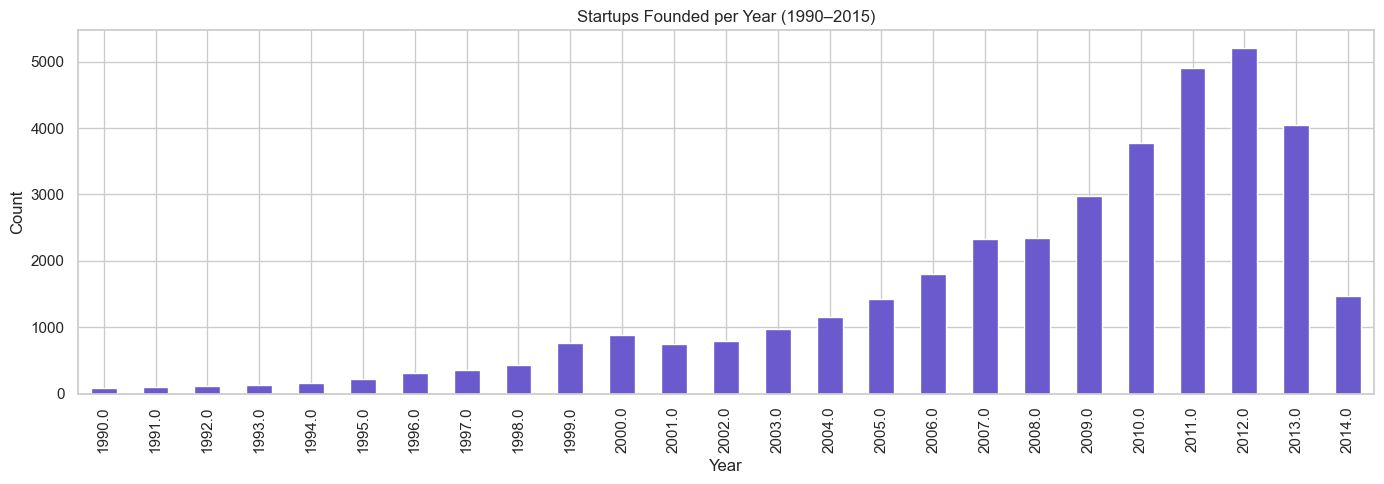

In [8]:
founded = df['founded_year'].dropna()
founded = founded[(founded >= 1990) & (founded <= 2015)]

fig, ax = plt.subplots(figsize=(14, 5))
founded.value_counts().sort_index().plot(kind='bar', ax=ax, color='slateblue')
ax.set_title('Startups Founded per Year (1990–2015)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 8. Median Funding by Country (Top 15)

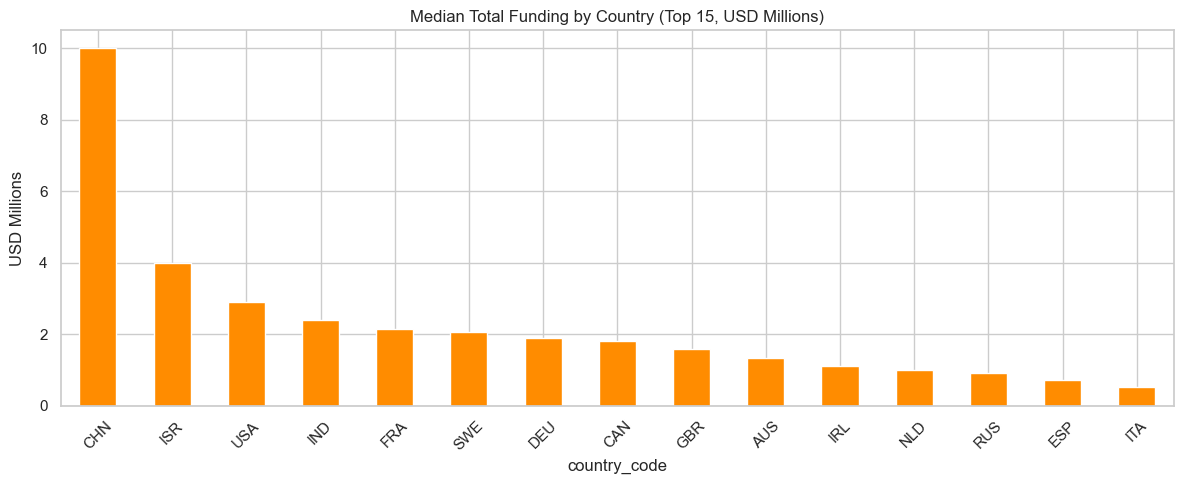

In [9]:
top_countries = df['country_code'].value_counts().head(15).index
country_funding = (
    df[df['country_code'].isin(top_countries)]
    .groupby('country_code')['funding_total_usd']
    .median()
    .sort_values(ascending=False)
    / 1e6
)

fig, ax = plt.subplots(figsize=(12, 5))
country_funding.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Median Total Funding by Country (Top 15, USD Millions)')
ax.set_ylabel('USD Millions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 9. Funding by Status

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_order = df.groupby('status')['funding_total_usd'].median().sort_values(ascending=False).index

# Left: median funding
df.groupby('status')['funding_total_usd'].median().reindex(status_order).div(1e6).plot(
    kind='bar', ax=axes[0], color=sns.color_palette('pastel'))
axes[0].set_title('Median Funding by Company Status (USD Millions)')
axes[0].set_ylabel('USD Millions')
axes[0].tick_params(axis='x', rotation=30)

# Right: count of startups
df['status'].value_counts().reindex(status_order).plot(
    kind='bar', ax=axes[1], color=sns.color_palette('pastel'))
axes[1].set_title('Number of Startups by Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 100),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Correlation Heatmap (Numeric Columns)

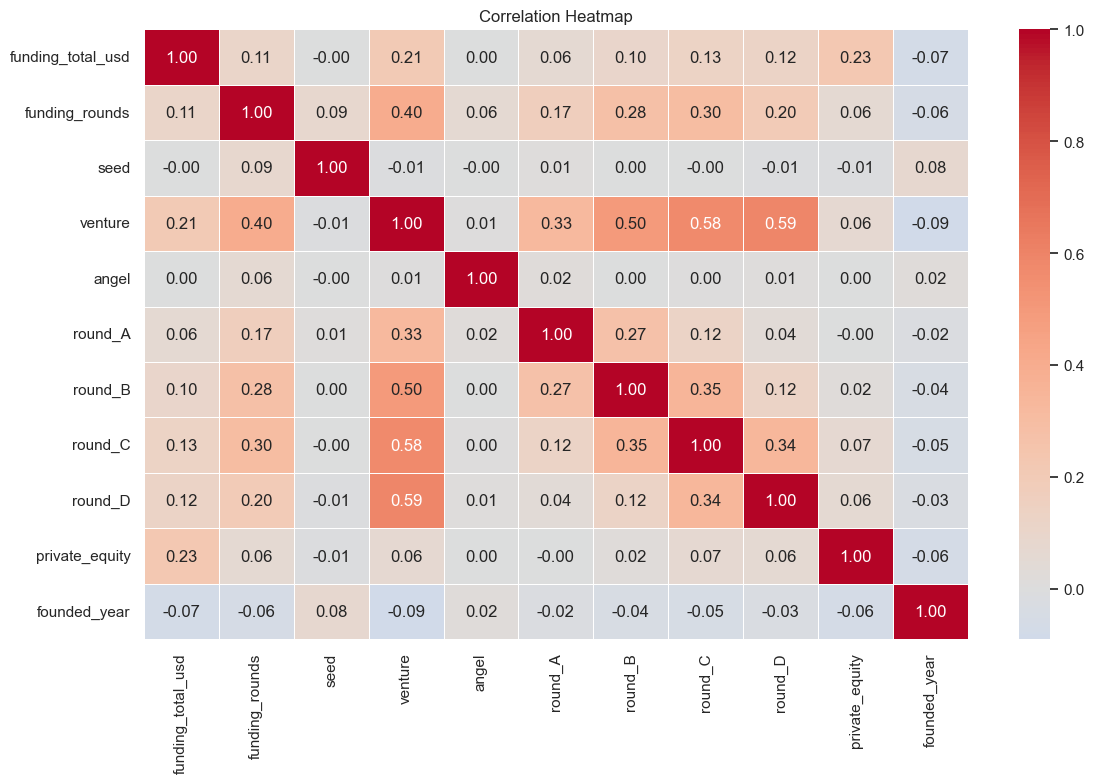

In [11]:
num_cols = ['funding_total_usd', 'funding_rounds', 'seed', 'venture', 'angel',
            'round_A', 'round_B', 'round_C', 'round_D', 'private_equity', 'founded_year']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 11. Key Takeaways\n\n- **Status**: Most companies are *operating*; ~20% were acquired.\n- **Geography**: USA dominates by volume; some smaller countries have higher median funding.\n- **Funding**: Highly right-skewed — a few companies raised massive rounds.\n- **Rounds**: Venture capital is the largest round type by total dollars.\n- **Trend**: Startup founding peaked around 2008–2014.\n- **Correlation**: `funding_rounds` and `funding_total_usd` are positively correlated — more rounds = more total raised.